### CREDIT CARD DEFAULT PREDICTION SYSTEM

 How well can we predict, month by month, the default of our clients? How well our model performs if we just use with respect to when we use 6 months of payment history?


## Variables
There are 25 variables:

* ID: ID of each client
* LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)
* SEX: Gender (1=male, 2=female)
* EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
* MARRIAGE: Marital status (1=married, 2=single, 3=others)
* AGE: Age in years
* PAY_0: Repayment status in September,  (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, ... 8=payment delay for eight months, 9=payment delay for nine months and above)
* PAY_2: Repayment status in August,  (scale same as above)
* PAY_3: Repayment status in July,  (scale same as above)
* PAY_4: Repayment status in June, (scale same as above)
* PAY_5: Repayment status in May,  (scale same as above)
* PAY_6: Repayment status in April,  (scale same as above)
* BILL_AMT1: Amount of bill statement in September,  (NT dollar)
* BILL_AMT2: Amount of bill statement in August,  (NT dollar)
* BILL_AMT3: Amount of bill statement in July,  (NT dollar)
* BILL_AMT4: Amount of bill statement in June,  (NT dollar)
* BILL_AMT5: Amount of bill statement in May,  (NT dollar)
* BILL_AMT6: Amount of bill statement in April,  (NT dollar)
* PAY_AMT1: Amount of previous payment in September,  (NT dollar)
* PAY_AMT2: Amount of previous payment in August,  (NT dollar)
* PAY_AMT3: Amount of previous payment in July, (NT dollar)
* PAY_AMT4: Amount of previous payment in June,  (NT dollar)
* PAY_AMT5: Amount of previous payment in May,  (NT dollar)
* PAY_AMT6: Amount of previous payment in April, (NT dollar)
* default.payment.next.month: Default payment (1=yes, 0=no)



In [1]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('credit_card_default_data.csv')
df.sample(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
13133,13134,260000,NaN,2,2,4h1,0,0,0,0,...,190432,105466,2312,9725,10617,8555,4722,2146,199485,1
17122,17123,50000,2,2,2,NaN,0,0,0,0,...,NaN,NaN,29921,1600,1715,2000,3010,2000,1f100,0
18967,18968,480000,2,2,2,30,NaN,0,NaN,-2,...,0,0,330982,0,0,0,0,330982,30000,1
10568,10569,350000,2,2,1,33,-1,-1,-2,-2,...,0,NaN,NaN,NaN,0,0,0,687,18296,NaN
6736,6737,30000,2,1,1,33,0,0,t0,0,...,28463,29303,29766,1500,1500,NaN,1300,1100,1032,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30100 entries, 0 to 30099
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          30100 non-null  int64 
 1   LIMIT_BAL                   27102 non-null  object
 2   SEX                         27150 non-null  object
 3   EDUCATION                   27007 non-null  object
 4   MARRIAGE                    27110 non-null  object
 5   AGE                         27092 non-null  object
 6   PAY_0                       27051 non-null  object
 7   PAY_2                       27082 non-null  object
 8   PAY_3                       27054 non-null  object
 9   PAY_4                       27059 non-null  object
 10  PAY_5                       27083 non-null  object
 11  PAY_6                       27061 non-null  object
 12  BILL_AMT1                   27081 non-null  object
 13  BILL_AMT2                   27127 non-null  ob

In [5]:
df.describe()

,ID
count,30100.000000
mean,15000.296545
std,8660.557664
min,1.000000
25%,7502.750000
50%,14998.500000
75%,22497.250000
max,30000.000000


In [6]:
# Categorical variables description
df[['SEX', 'EDUCATION', 'MARRIAGE']].describe()

,SEX,EDUCATION,MARRIAGE
count,27150,27007,27110
unique,106,183,125
top,2,2,2
freq,15570,12018,13726


In [7]:
# Payment delay description
df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].describe()

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,27051,27082,27054,27059,27083,27061
unique,256,226,214,220,219,221
top,0,0,0,0,0,0
freq,12617,13495,13460,14115,14519,13997


In [8]:
# Bill Statement description
df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,27081,27127,27095,27022,27124,27021
unique,21169,20816,20467,20031,19691,19214
top,0,0,0,0,0,0
freq,1700,2161,2448,2757,2983,3453


In [9]:
for col in df.columns: 
    print(col) 
    print(df[col].unique())

ID
[    1     2     3 ... 29998 29999 30000]
LIMIT_BAL
['20000' '120000' '90000' ... '27000f0' '16000r0' '80A000']
SEX
['2' '1' nan 'g2' 'Q2' 'p1' 'I1' 'k2' 's2' 'O2' 'o2' 'X2' 'f2' 'J2' 'L2'
 'h1' 'F2' 'i2' 'Z1' 'D1' 'j2' 's1' 'I2' 'z1' 'u2' 'U2' 'R2' 'v2' 'h2'
 'A2' 'M2' 'C2' 'X1' 'w1' 'F1' 'B2' 'v1' 'N1' 'Y2' 'H2' 'n1' 'm2' 'T1'
 'c2' 'S2' 'K1' 'e2' 'U1' 'K2' 'd1' 'Q1' 'd2' 'r2' 'l1' 'n2' 'o1' 'O1'
 'f1' 'b1' 'l2' 'D2' 'q2' 'b2' 'J1' 'e1' 'V2' 'P1' 'a2' 'H1' 'G1' 't1'
 'M1' 'j1' 'p2' 'Y1' 'x1' 'V1' 'w2' 'N2' 'y1' 'B1' 'k1' 'E1' 'W2' 't2'
 'c1' 'R1' 'C1' 'z2' 'x2' 'r1' 'q1' 'm1' 'G2' 'A1' 'Z2' 'g1' 'T2' 'E2'
 'P2' 'S1' 'a1' 'L1' 'u1' 'W1' 'y2' 'i1']
EDUCATION
['2' nan '1' '3' 'M3' 'Z1' 'f2' '5' 'M1' 'O1' 'h2' 'a1' 'v1' 'y3' 'f3'
 'O3' '4' 's5' 'q1' 'h3' 'b1' 'f1' 'o2' '6' 't1' 'R1' 'n1' 'V1' 'x3' 'E1'
 'C1' 'T3' 'P2' 'S2' 'U3' 'A2' 'T1' 'i2' 'w3' 'p3' 'm2' 'H2' 'H3' 'I2'
 'H1' 't2' 'B2' 'a3' 'a2' 's1' 'S1' 'M2' 'J2' 'e1' 'P3' 'T2' 'Y1' 'K2'
 'y2' 'C2' 'L1' 'I3' 'W2' 'k1' 'n2' 'w1' 'L

In [10]:
df.shape


(30100, 25)

In [11]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)
df.shape 

(30084, 25)

In [12]:
df.drop("ID", axis=1, inplace=True)


In [13]:
df.columns


Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

# DATA CLEANING

Cleaning all columns with missing , unclean or nan values.

In [14]:
df.rename(columns={
    "LIMIT_BAL":"LIMIT_BAL",
    "SEX":"SEX",
    "EDUCATION":"EDUCATION",
    "MARRIAGE":"MARRIAGE",
    "AGE":"AGE",
    "default payment next month":"DEFAULT"
}, inplace=True)




# 2. SEX (extract numeric only)
df["SEX"] = df["SEX"].astype(str)
df["SEX"] = df["SEX"].str.extract(r'(\d+)')
df["SEX"] = pd.to_numeric(df["SEX"], errors="coerce")

# 3. EDUCATION (extract numeric only)
df["EDUCATION"] = df["EDUCATION"].astype(str)
df["EDUCATION"] = df["EDUCATION"].str.extract(r'(\d+)')
df["EDUCATION"] = pd.to_numeric(df["EDUCATION"], errors="coerce")

# 4. MARRIAGE (extract numeric only)
df["MARRIAGE"] = df["MARRIAGE"].astype(str)
df["MARRIAGE"] = df["MARRIAGE"].str.extract(r'(\d+)')
df["MARRIAGE"] = pd.to_numeric(df["MARRIAGE"], errors="coerce")

# 5. AGE (extract numeric only)
df["AGE"] = df["AGE"].astype(str)
df["AGE"] = df["AGE"].str.extract(r'(\d+)')
df["AGE"] = pd.to_numeric(df["AGE"], errors="coerce")

# 6. LIMIT_BAL (strip letters, keep digits)
df["LIMIT_BAL"] = df["LIMIT_BAL"].astype(str)
df["LIMIT_BAL"] = df["LIMIT_BAL"].str.replace(r"[^\d\.\-]", "", regex=True)
df["LIMIT_BAL"] = pd.to_numeric(df["LIMIT_BAL"], errors="coerce")

# 7. PAY_0
df["PAY_0"] = df["PAY_0"].astype(str)
df["PAY_0"] = df["PAY_0"].str.replace(r"[^\d\-]", "", regex=True)
df["PAY_0"] = pd.to_numeric(df["PAY_0"], errors="coerce")

# 8. PAY_2
df["PAY_2"] = df["PAY_2"].astype(str)
df["PAY_2"] = df["PAY_2"].str.replace(r"[^\d\-]", "", regex=True)
df["PAY_2"] = pd.to_numeric(df["PAY_2"], errors="coerce")

# 9. PAY_3
df["PAY_3"] = df["PAY_3"].astype(str)
df["PAY_3"] = df["PAY_3"].str.replace(r"[^\d\-]", "", regex=True)
df["PAY_3"] = pd.to_numeric(df["PAY_3"], errors="coerce")

# 10. PAY_4
df["PAY_4"] = df["PAY_4"].astype(str)
df["PAY_4"] = df["PAY_4"].str.replace(r"[^\d\-]", "", regex=True)
df["PAY_4"] = pd.to_numeric(df["PAY_4"], errors="coerce")

# 11. PAY_5
df["PAY_5"] = df["PAY_5"].astype(str)
df["PAY_5"] = df["PAY_5"].str.replace(r"[^\d\-]", "", regex=True)
df["PAY_5"] = pd.to_numeric(df["PAY_5"], errors="coerce")

# 12. PAY_6
df["PAY_6"] = df["PAY_6"].astype(str)
df["PAY_6"] = df["PAY_6"].str.replace(r"[^\d\-]", "", regex=True)
df["PAY_6"] = pd.to_numeric(df["PAY_6"], errors="coerce")

# 13. BILL_AMT1–6 
df["BILL_AMT1"] = df["BILL_AMT1"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["BILL_AMT1"] = pd.to_numeric(df["BILL_AMT1"], errors="coerce")

df["BILL_AMT2"] = df["BILL_AMT2"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["BILL_AMT2"] = pd.to_numeric(df["BILL_AMT2"], errors="coerce")

df["BILL_AMT3"] = df["BILL_AMT3"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["BILL_AMT3"] = pd.to_numeric(df["BILL_AMT3"], errors="coerce")

df["BILL_AMT4"] = df["BILL_AMT4"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["BILL_AMT4"] = pd.to_numeric(df["BILL_AMT4"], errors="coerce")

df["BILL_AMT5"] = df["BILL_AMT5"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["BILL_AMT5"] = pd.to_numeric(df["BILL_AMT5"], errors="coerce")

df["BILL_AMT6"] = df["BILL_AMT6"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["BILL_AMT6"] = pd.to_numeric(df["BILL_AMT6"], errors="coerce")

# 14. PAY_AMT1–6
df["PAY_AMT1"] = df["PAY_AMT1"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["PAY_AMT1"] = pd.to_numeric(df["PAY_AMT1"], errors="coerce")

df["PAY_AMT2"] = df["PAY_AMT2"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["PAY_AMT2"] = pd.to_numeric(df["PAY_AMT2"], errors="coerce")

df["PAY_AMT3"] = df["PAY_AMT3"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["PAY_AMT3"] = pd.to_numeric(df["PAY_AMT3"], errors="coerce")

df["PAY_AMT4"] = df["PAY_AMT4"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["PAY_AMT4"] = pd.to_numeric(df["PAY_AMT4"], errors="coerce")

df["PAY_AMT5"] = df["PAY_AMT5"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["PAY_AMT5"] = pd.to_numeric(df["PAY_AMT5"], errors="coerce")

df["PAY_AMT6"] = df["PAY_AMT6"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
df["PAY_AMT6"] = pd.to_numeric(df["PAY_AMT6"], errors="coerce")


# target column
df["DEFAULT"] = df["DEFAULT"].astype(str).str.extract(r"(\d)")
df["DEFAULT"] = pd.to_numeric(df["DEFAULT"], errors="coerce")


df = df.fillna(df.median(numeric_only=True))



## Categorical variables

That are SEX, MARRIAGE, EDUCATION, see both how our dataset is divided and if there are sparse classes which can cause overfit of our models.

<Axes: xlabel='EDUCATION'>

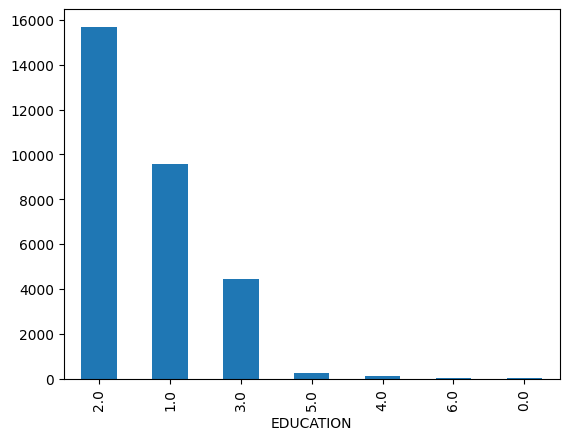

In [15]:
df.EDUCATION.value_counts().plot(kind = "bar")

<Axes: xlabel='SEX'>

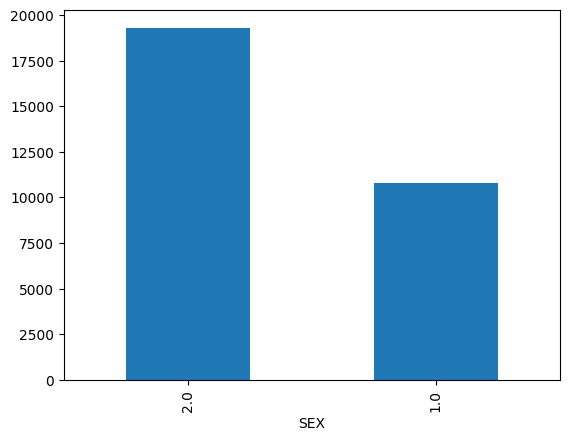

In [16]:
df.SEX.value_counts().plot(kind = "bar")

<Axes: >

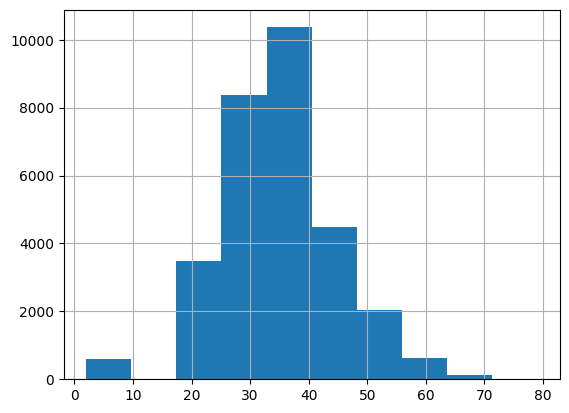

In [17]:
df.AGE.hist()

<Axes: >

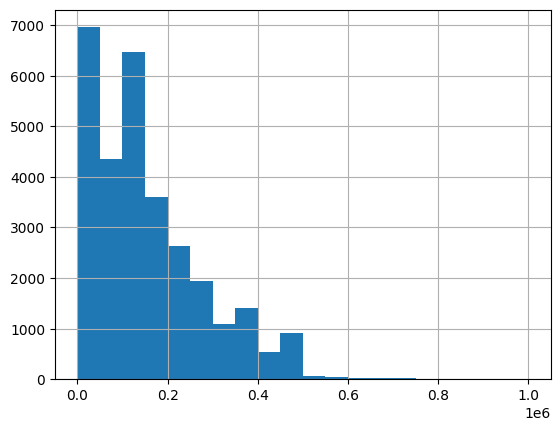

In [18]:
df.LIMIT_BAL.hist(bins = 20)

As seen previously, some categories are mislabeled or undocumented.

The 0 in MARRIAGE can be safely categorized as 'Other' (thus 3). 

The 0 (undocumented), 5 and 6 (label unknown) in EDUCATION can also be put in a 'Other' cathegory (thus 4)

In [19]:
fil = (df.EDUCATION == 5) | (df.EDUCATION == 6) | (df.EDUCATION == 0)
df.loc[fil, 'EDUCATION'] = 4
df.EDUCATION.value_counts()

EDUCATION
2.0    15690
1.0     9549
3.0     4426
4.0      419
Name: count, dtype: int64

In [20]:
df.loc[df.MARRIAGE == 0, 'MARRIAGE'] = 3
df.MARRIAGE.value_counts()

MARRIAGE
2.0    17437
1.0    12298
3.0      349
Name: count, dtype: int64

### Each gender to default 

In [21]:
df.groupby(['SEX', 'DEFAULT']).size()

SEX  DEFAULT
1.0  0.0         8424
     1.0         2357
2.0  0.0        15683
     1.0         3620
dtype: int64

In [22]:
pd.crosstab(df.SEX, df.DEFAULT)

DEFAULT,0.0,1.0
SEX,,
1.0,8424,2357
2.0,15683,3620


In [23]:
df[["SEX", "DEFAULT"]].groupby(['SEX']).mean().sort_values(by='DEFAULT')

,DEFAULT
SEX,
2.0,0.187536
1.0,0.218625


Considering that about 22% of the customers will default, we see a couple of things:
* there are significantly more women than men
* men are most likely going to default the next month


In [24]:
def corr_2_cols(Col1, Col2):
    res = df.groupby([Col1, Col2]).size().unstack()
    res['percentage'] = (res[res.columns[1]]/(res[res.columns[0]] + res[res.columns[1]]))
    return res

In [25]:
corr_2_cols('EDUCATION', 'DEFAULT')

DEFAULT,0.0,1.0,percentage
EDUCATION,,,
1.0,7894,1655,0.173317
2.0,12391,3299,0.210261
3.0,3430,996,0.225034
4.0,392,27,0.064439


It seems that the higher is the education, the lower is the probability of defaulting the next month.

In [26]:
corr_2_cols('MARRIAGE', 'DEFAULT')

DEFAULT,0.0,1.0,percentage
MARRIAGE,,,
1.0,9672,2626,0.213531
2.0,14165,3272,0.187647
3.0,270,79,0.226361


Here it seems that married people are most likely to default as well as the   Other category.

In [27]:
df['SE_MA'] = 0
df.loc[((df.SEX == 1) & (df.MARRIAGE == 1)) , 'SE_MA'] = 1 #married man
df.loc[((df.SEX == 1) & (df.MARRIAGE == 2)) , 'SE_MA'] = 2 #single man
df.loc[((df.SEX == 1) & (df.MARRIAGE == 3)) , 'SE_MA'] = 3 #other man
df.loc[((df.SEX == 2) & (df.MARRIAGE == 1)) , 'SE_MA'] = 4 #married woman
df.loc[((df.SEX == 2) & (df.MARRIAGE == 2)) , 'SE_MA'] = 5 #single woman
df.loc[((df.SEX == 2) & (df.MARRIAGE == 3)) , 'SE_MA'] = 6 #other woman
corr_2_cols('SE_MA', 'DEFAULT')

DEFAULT,0.0,1.0,percentage
SE_MA,,,
1,3229,1004,0.237184
2,5106,1316,0.204921
3,89,37,0.293651
4,6443,1622,0.201116
5,9059,1956,0.177576
6,181,42,0.188341


Married men have a higher probability of defaulting, single men have nothing special with respect to the all population and single women have a lowe probability of defaulting

This is a classification problem and this means that we can use the following algorithms:

* Logistic regression,
* Decision tree,
* Random forest,
* Support Vector Classifications
* Stocastic Gradient Descend
* Nearest Neighbours Classifiers
* Gaussian Process Classification
* Other ensemble
* Neural Network Models
* XGBoost

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

features = ['LIMIT_BAL', 'EDUCATION', 'MARRIAGE', 'PAY_0','PAY_2', 'PAY_3', 
            'PAY_4', 'PAY_5', 'PAY_6','BILL_AMT1', 'BILL_AMT2',
            'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
            'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 
            'SE_MA',]
y = df['DEFAULT'].copy() # target
x = df[features].copy()

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=42)

scaler = MinMaxScaler()
x_tr = scaler.fit_transform(xtrain)
x_te = scaler.transform(xtest)

In [29]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(x_tr, ytrain)
ypred_logreg = logreg.predict(x_te)

In [30]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_tr, ytrain)
ypred_dt = dt.predict(x_te)

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(x_tr, ytrain)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_probs = rf.predict_proba(x_te)[:, 1]

THRESHOLD = 0.30

ypred_rf = (y_probs >= THRESHOLD).astype(int)



In [36]:
import joblib

# Save trained model
joblib.dump(rf, "credit_default_rf_balanced.joblib")

# Save scaler (so you can reuse it in Streamlit)
joblib.dump(scaler, "scaler.joblib")

# Save feature list (from original DataFrame, not NumPy array)
joblib.dump(features, "features.joblib")

['features.joblib']

In [37]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(x_tr, ytrain)
ypred_svm = svm.predict(x_te)

In [38]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_tr, ytrain)
ypred_knn = knn.predict(x_te)

In [39]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier()
ada.fit(x_tr, ytrain)
ypred_ada = ada.predict(x_te)

In [40]:
# from xgboost import XGBClassifier

# xgb = XGBClassifier(eval_metric='logloss') 
# xgb.fit(x_tr, ytrain)
# ypred_xgb = xgb.predict(x_te)

In [41]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest, ypred_rf)
print(cm)


[[6387  868]
 [ 887  884]]


In [42]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(ytest, ypred_logreg))
print("Decision Tree:\n", classification_report(ytest, ypred_dt))
print("Random Forest:\n", classification_report(ytest, ypred_rf))
print("SVM:\n", classification_report(ytest, ypred_svm))
print("KNN:\n", classification_report(ytest, ypred_knn))
print("AdaBoost:\n", classification_report(ytest, ypred_ada))
# print("XGBoost:\n", classification_report(ytest, ypred_xgb))

Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.82      0.98      0.89      7255
         1.0       0.63      0.13      0.22      1771

    accuracy                           0.81      9026
   macro avg       0.73      0.56      0.56      9026
weighted avg       0.78      0.81      0.76      9026

Decision Tree:
               precision    recall  f1-score   support

         0.0       0.84      0.82      0.83      7255
         1.0       0.33      0.36      0.34      1771

    accuracy                           0.73      9026
   macro avg       0.58      0.59      0.59      9026
weighted avg       0.74      0.73      0.73      9026

Random Forest:
               precision    recall  f1-score   support

         0.0       0.88      0.88      0.88      7255
         1.0       0.50      0.50      0.50      1771

    accuracy                           0.81      9026
   macro avg       0.69      0.69      0.69      9026
weighted avg       0

In [43]:
from sklearn.metrics import classification_report

for threshold in [0.5, 0.4, 0.35, 0.3, 0.25]:
    y_pred_custom = (y_probs >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(classification_report(ytest, y_pred_custom))



Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.84      0.96      0.90      7255
         1.0       0.62      0.26      0.37      1771

    accuracy                           0.82      9026
   macro avg       0.73      0.61      0.63      9026
weighted avg       0.80      0.82      0.79      9026


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.86      0.93      0.89      7255
         1.0       0.57      0.38      0.45      1771

    accuracy                           0.82      9026
   macro avg       0.71      0.65      0.67      9026
weighted avg       0.80      0.82      0.81      9026


Threshold: 0.35
              precision    recall  f1-score   support

         0.0       0.87      0.91      0.89      7255
         1.0       0.55      0.44      0.49      1771

    accuracy                           0.82      9026
   macro avg       0.71      0.67      0.69      9026
weighted avg       0.81  

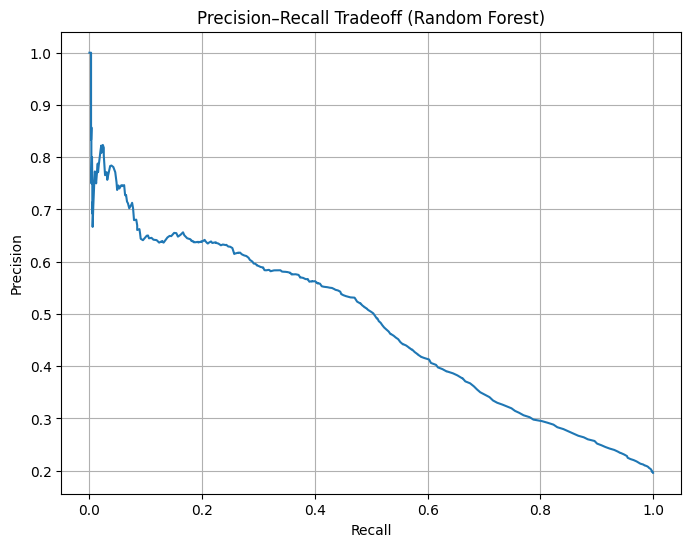

In [44]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(ytest, y_probs)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Tradeoff (Random Forest)")
plt.grid(True)
plt.show()


In [45]:
import mlflow
import mlflow.sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, recall_score, f1_score

THRESHOLD = 0.30

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Credit_Default_Risk")


c:\Users\Abhay Singh\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///d:/ML_PROJECT/mlruns/825906562512054622', creation_time=1768936775228, experiment_id='825906562512054622', last_update_time=1768936775228, lifecycle_stage='active', name='Credit_Default_Risk', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [46]:
with mlflow.start_run(run_name="LogisticRegression"):

    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(x_tr, ytrain)

    y_probs = model.predict_proba(x_te)[:, 1]
    ypred = (y_probs >= THRESHOLD).astype(int)

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("threshold", THRESHOLD)

    mlflow.log_metric("accuracy", accuracy_score(ytest, ypred))
    mlflow.log_metric("recall", recall_score(ytest, ypred))
    mlflow.log_metric("f1_score", f1_score(ytest, ypred))

    mlflow.sklearn.log_model(model, "model")


2026/01/25 21:02:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [47]:
with mlflow.start_run(run_name="DecisionTree"):

    model = DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    model.fit(x_tr, ytrain)

    y_probs = model.predict_proba(x_te)[:, 1]
    ypred = (y_probs >= THRESHOLD).astype(int)

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("threshold", THRESHOLD)

    mlflow.log_metric("accuracy", accuracy_score(ytest, ypred))
    mlflow.log_metric("recall", recall_score(ytest, ypred))
    mlflow.log_metric("f1_score", f1_score(ytest, ypred))

    mlflow.sklearn.log_model(model, "model")


2026/01/25 21:02:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [48]:
with mlflow.start_run(run_name="RandomForest_balanced"):

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(x_tr, ytrain)

    y_probs = model.predict_proba(x_te)[:, 1]
    ypred = (y_probs >= THRESHOLD).astype(int)

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("threshold", THRESHOLD)

    mlflow.log_metric("accuracy", accuracy_score(ytest, ypred))
    mlflow.log_metric("recall", recall_score(ytest, ypred))
    mlflow.log_metric("f1_score", f1_score(ytest, ypred))

    mlflow.sklearn.log_model(model, "model")


2026/01/25 21:03:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [49]:
with mlflow.start_run(run_name="SVM"):

    model = SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    )

    model.fit(x_tr, ytrain)

    y_probs = model.predict_proba(x_te)[:, 1]
    ypred = (y_probs >= THRESHOLD).astype(int)

    mlflow.log_param("model", "SVM")
    mlflow.log_param("threshold", THRESHOLD)

    mlflow.log_metric("accuracy", accuracy_score(ytest, ypred))
    mlflow.log_metric("recall", recall_score(ytest, ypred))
    mlflow.log_metric("f1_score", f1_score(ytest, ypred))

    mlflow.sklearn.log_model(model, "model")


2026/01/25 21:06:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [50]:
with mlflow.start_run(run_name="KNN"):

    model = KNeighborsClassifier(n_neighbors=5)

    model.fit(x_tr, ytrain)

    y_probs = model.predict_proba(x_te)[:, 1]
    ypred = (y_probs >= THRESHOLD).astype(int)

    mlflow.log_param("model", "KNN")
    mlflow.log_param("n_neighbors", 5)
    mlflow.log_param("threshold", THRESHOLD)

    mlflow.log_metric("accuracy", accuracy_score(ytest, ypred))
    mlflow.log_metric("recall", recall_score(ytest, ypred))
    mlflow.log_metric("f1_score", f1_score(ytest, ypred))

    mlflow.sklearn.log_model(model, "model")


2026/01/25 21:06:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [51]:
with mlflow.start_run(run_name="AdaBoost"):

    model = AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    )

    model.fit(x_tr, ytrain)

    y_probs = model.predict_proba(x_te)[:, 1]
    ypred = (y_probs >= THRESHOLD).astype(int)

    mlflow.log_param("model", "AdaBoost")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("threshold", THRESHOLD)

    mlflow.log_metric("accuracy", accuracy_score(ytest, ypred))
    mlflow.log_metric("recall", recall_score(ytest, ypred))
    mlflow.log_metric("f1_score", f1_score(ytest, ypred))

    mlflow.sklearn.log_model(model, "model")


2026/01/25 21:06:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [52]:
# http://localhost:5000
# streamlit run app.py

In [53]:
for threshold in [0.5, 0.4, 0.3, 0.2]:
    with mlflow.start_run(run_name=f"RF_threshold_{threshold}"):

        ypred_rf = (y_probs >= threshold).astype(int)

        accuracy = accuracy_score(ytest, ypred_rf)
        recall = recall_score(ytest, ypred_rf)
        f1 = f1_score(ytest, ypred_rf)

        mlflow.log_param("threshold", threshold)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
